# **Анализ исторических данных и дизайн A/B-теста**

## Цель проекта
На основе исторических данных пользователей Marketpele необходимо:
1. Провести предобработку данных
2. Изучить закономерности в данных (EDA)
3. Спроектировать A/B-тест для проверки гипотезы об изменении расположения платных и органических элементов
4. Определить метрики, длительность и минимальный детектируемый эффект


## **Часть 1. Предобработка данных**
Проверим типы данных, пропуски и выбросы, при необходимости обработаем их.

### **1a. Проверка типов данных**

Если числовая колонка хранится как текст, нельзя посчитать среднее, медиану и т.д. <br>
Загружаем данные и проверяем тип каждой колонки.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x:'{:.4f}'.format(x))

In [2]:
# Загружаем данные
df = pd.read_csv('user_activity_data.csv', sep=',', encoding='windows-1251')
df.head()

,date,user_id,device,pages_viewed,paid_clicks,organic_clicks,revenue
0,2026-01-01,1,mobile,18,6,0,11.3000
1,2026-01-01,4,desktop,6,0,4,5.1300
2,2026-01-01,6,desktop,6,2,0,3.8900
3,2026-01-01,9,mobile,12,1,12,9.5100
4,2026-01-01,11,mobile,15,3,7,13.6900


In [3]:
# Смотрим типы данных
print(df.dtypes)

date               object
user_id             int64
device             object
pages_viewed        int64
paid_clicks         int64
organic_clicks      int64
revenue           float64
dtype: object


In [4]:
# Исправим только колонку date, чтобы она была в формате datetime, чтобы Python воспринимал её как дату
df['date'] = pd.to_datetime(df['date'])

print(df.dtypes)

date              datetime64[ns]
user_id                    int64
device                    object
pages_viewed               int64
paid_clicks                int64
organic_clicks             int64
revenue                  float64
dtype: object


### **1b. Проверка пропусков**
Пропуски искажают статистику: средние значения, корреляции и выводы могут быть неверными. Проверяем, есть ли пропуски в данных и дубликаты.

In [5]:
# Проверяем пропуски
print("Пропуски по колонкам")
print(df.isnull().sum())

# Проверяем дубликаты
print(f'\nКоличество дубликатов: {df.duplicated().sum()}')


Пропуски по колонкам
date              0
user_id           0
device            0
pages_viewed      0
paid_clicks       0
organic_clicks    0
revenue           0
dtype: int64

Количество дубликатов: 0


##### **Результат 1b:**
Вывод: Пропусков и дубликатов нет — данные чистые, можно переходить к обработке выбросов.

### **1c. Обработка выбросов**
Выбросы могут искажать средние значения и влиять на результаты теста.  
Используем метод IQR: значения, выходящие за границы `Q1 - 1.5*IQR` и `Q3 + 1.5*IQR`, считаем выбросами.

Покажем выбросы на boxplot. Это поможет наглядно увидеть, какие метрики самые нестабильные.

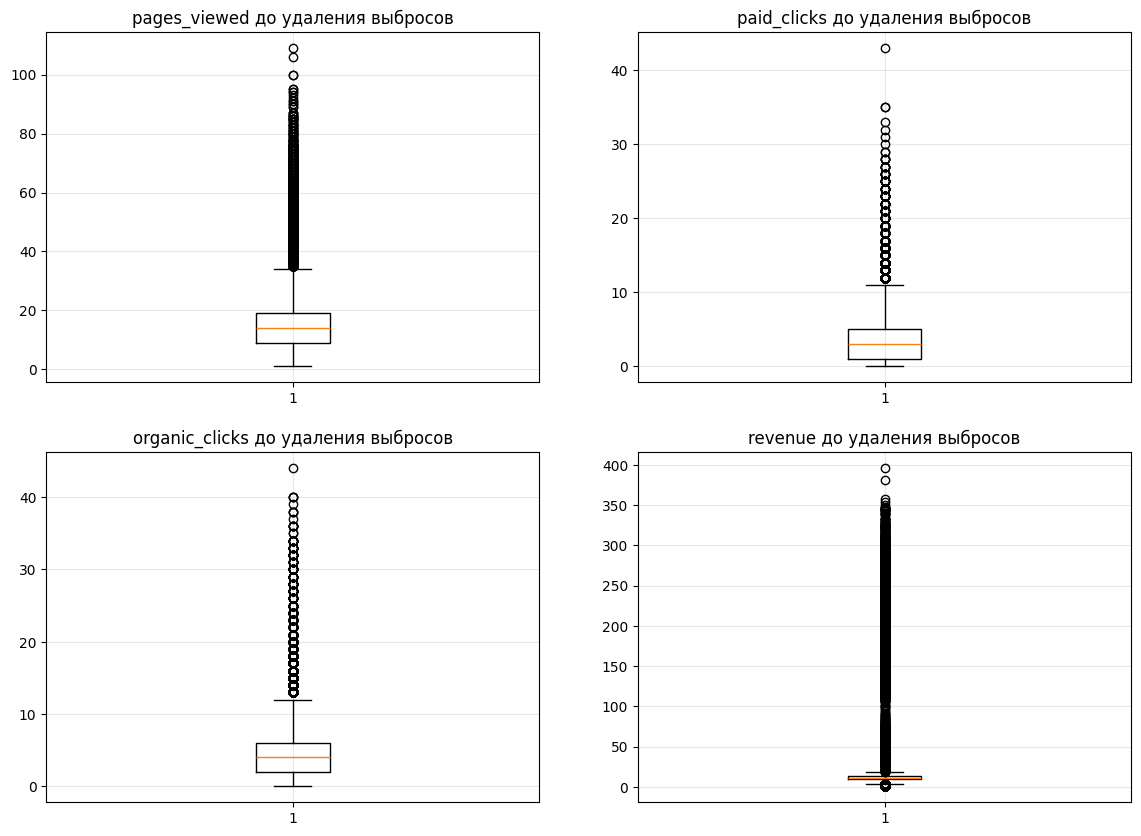

In [6]:
columns_num = ['pages_viewed', 'paid_clicks', 'organic_clicks', 'revenue']

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.ravel()

for i, col in enumerate(columns_num):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col} до удаления выбросов')
    axes[i].grid(True, alpha=0.3)

#### **Результат визуализации выбросов**
На boxplot видно, что:
- `pages_viewed`, `paid_clicks`, `organic_clicks` — есть небольшое количество выбросов сверху, основная масса данных лежит кучно.
- `revenue` — много выбросов сверху, максимальные значения сильно отрываются от основной массы.

Это подтверждает, что `revenue` — самая нестабильная метрика и именно она требует очистки от выбросов.

In [7]:
# Считаем границы выбросов методом IQR 

for col in columns_num:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}:")
    print(f"  Границы: {lower:.2f} до {upper:.2f}")
    print(f"  Выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")


pages_viewed:
  Границы: -6.00 до 34.00
  Выбросов: 1914 (2.14%)
  Min: 1, Max: 109

paid_clicks:
  Границы: -5.00 до 11.00
  Выбросов: 1203 (1.35%)
  Min: 0, Max: 43

organic_clicks:
  Границы: -4.00 до 12.00
  Выбросов: 2327 (2.60%)
  Min: 0, Max: 44

revenue:
  Границы: 3.28 до 18.96
  Выбросов: 14332 (16.04%)
  Min: 0.52, Max: 395.72


#### **Анализ выбросов:**
Больше всего выбросов в `revenue` — **16%**.  
Если удалим их все с порогом `1.5*IQR`, потеряем слишком много данных, особенно по `revenue`.  

Поэтому для удаления используем более мягкий порог — `3*IQR`.  
Это уберёт только самые аномальные значения, не потеряв значительную часть данных.

#### **Удаление выбросов:**
Используем метод IQR с порогом `3*IQR`. Это мягкий вариант, который убирает только экстремальные значения.

In [8]:
# Удалляем выбросы с мягким порогом 3 * IQR
df_clean = df.copy()

for col in columns_num:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 3 * IQR
    upper = q3 + 3 * IQR

    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    removed = before - len(df_clean)

    print(f"{col}: удалено {removed} строк ({removed/len(df)*100:.2f}%)")

print(f"\nБыло строк: {len(df)}")
print(f"Стало строк: {len(df_clean)}")
print(f"Удалено всего: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

pages_viewed: удалено 896 строк (1.00%)
paid_clicks: удалено 191 строк (0.21%)
organic_clicks: удалено 507 строк (0.57%)
revenue: удалено 2558 строк (2.86%)

Было строк: 89353
Стало строк: 85201
Удалено всего: 4152 (4.65%)


### **1d. Сравнение метрик до и после удаления выбросов**
Смотрим, как изменились средние, медианы и стандартные отклонения.  
Если метрики изменились сильно — значит выбросы сильно искажали картину.

In [9]:
# Сравнение до и после
comprasion = pd.DataFrame({
    'Среднее до': [df[col].mean() for col in columns_num],
    'Среднее после': [df_clean[col].mean() for col in columns_num],
    'Медиана до': [df[col].median() for col in columns_num],
    'Медиана после': [df_clean[col].median() for col in columns_num],
    'Std до': [df[col].std() for col in columns_num],
    'Std после': [df_clean[col].std() for col in columns_num]
}, index=columns_num)

comprasion

,Среднее до,Среднее после,Медиана до,Медиана после,Std до,Std после
pages_viewed,14.7072,14.2183,14.0000,14.0000,8.5666,7.1593
paid_clicks,3.2382,3.1875,3.0000,3.0000,2.7937,2.6563
organic_clicks,4.5339,4.4152,4.0000,4.0000,3.4854,3.1576
revenue,15.0818,10.1376,11.3700,11.2600,31.8077,4.1093


#### **Вывод по сравнению метрик**:
- Медианы почти не изменились — выбросы были в основном сверху.
- Сильнее всего изменился `revenue`: среднее упало с **15.08** до **10.14**, а стандартное отклонение с **31.81** до **4.11**.  
  Это значит, что именно в `revenue` были экстремальные значения, которые сильно искажали статистику.

Данные стали чище и стабильнее. Можно переходить к изучению датасета.

## **Часть 2. Изучение датасета**

### **2a. Сколько пользователей в датасете**
Смотрим общее количество записей и уникальных пользователей.  
Это нужно, чтобы понимать масштаб данных и сколько пользователей участвует в тесте.

In [10]:
print(f'Всего записей: {len(df_clean)}')
print(f'Уникальных пользователей: {df_clean['user_id'].nunique()}')

# Сколько раз встречается каждый пользователь
visits_per_user = df_clean.groupby('user_id').size()

print(f"\nПользователей с одним визитом: {(visits_per_user == 1).sum()}")
print(f"Пользователей с несколькими визитами: {(visits_per_user > 1).sum()}")
print(f"Максимум визитов на одного пользователя: {visits_per_user.max()}")

Всего записей: 85201
Уникальных пользователей: 3000

Пользователей с одним визитом: 1
Пользователей с несколькими визитами: 2999
Максимум визитов на одного пользователя: 56


### **2b. Период данных**
Смотрим, за какой период представлены данные и насколько равномерно пользователи распределены по дням.

In [11]:
# Посмотрим период времени, за который у нас есть данные
print(f'Минимальная дата: {df["date"].dt.date.min()}')
print(f'Максимальная дата: {df["date"].dt.date.max()}')
print(f'Количество дней: {(df['date'].dt.date.max() - df['date'].dt.date.min()).days}')

daily_users = df_clean.groupby('date', as_index=False).agg({
    'user_id':'count',
    'revenue':'mean'
})
print("\nСреднее количество пользователей в день:", round(daily_users['user_id'].mean(), 0))
print("Мин пользователей в день:", daily_users['user_id'].min())
print("Макс пользователей в день:", daily_users['user_id'].max())
print(f'Стандартное отклонение по срднему доходу пользователя: {daily_users['revenue'].std()}')
daily_users.head()

Минимальная дата: 2026-01-01
Максимальная дата: 2026-02-25
Количество дней: 55

Среднее количество пользователей в день: 1521.0
Мин пользователей в день: 1475
Макс пользователей в день: 1563
Стандартное отклонение по срднему доходу пользователя: 0.061262009194350646


,date,user_id,revenue
0,2026-01-01,1550,10.0853
1,2026-01-02,1526,10.2194
2,2026-01-03,1529,10.1534
3,2026-01-04,1475,10.1129
4,2026-01-05,1552,10.2124


#### **Результат 2b:**
- Данные охватывают **55 дней** — с 1 января по 25 февраля 2026.
- В день в среднем **1 521 пользователь**.
- Количество пользователей по дням почти не меняется: от **1 475** до **1 563**.
- Средний доход на пользователя тоже стабилен.

Активность равномерная, без явных провалов или всплесков.

### 2c. Распределение метрик
Для наглядного анализа распределений используем violin plot.  
Он показывает плотность распределения и выбросы.

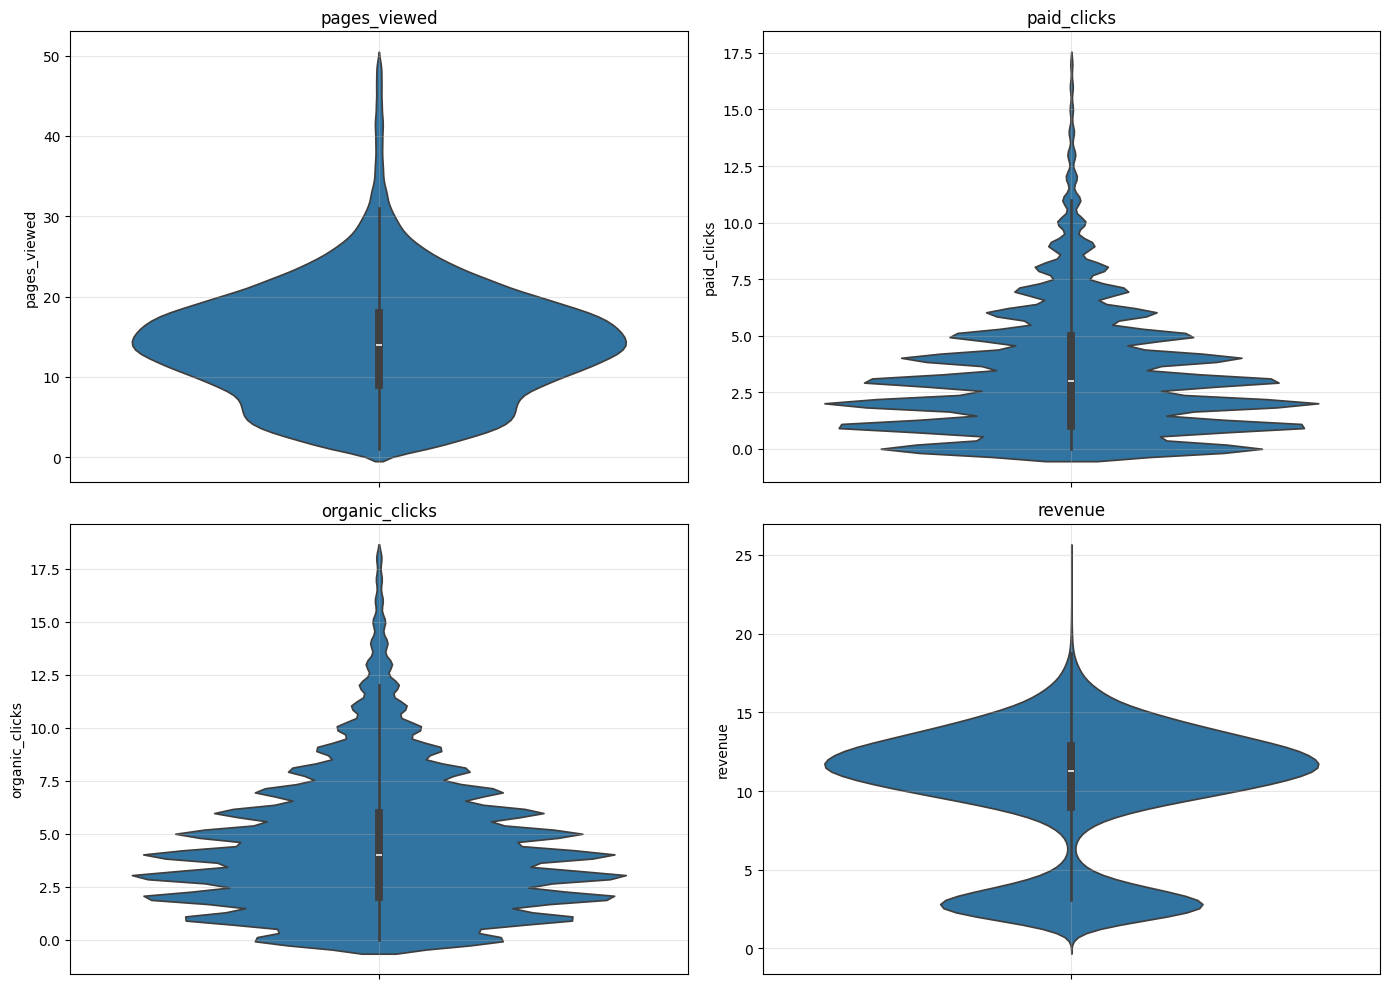

In [12]:
# Violin plot для основных метрик
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(columns_num):
    sns.violinplot(data=df_clean, y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Вывод по violin plot:**

**pages_viewed**  
Основная масса пользователей просматривает от 9 до 18 страниц. Хвост уходит вверх — есть пользователи, которые просматривают значительно больше.

**paid_clicks**  
Большинство пользователей совершает от 1 до 5 кликов по рекламе. Хвост вверх — небольшая группа кликает намного чаще.

**organic_clicks**  
Похожая картина: основная масса — от 2 до 6 кликов, хвост вверх — есть пользователи с высокой активностью.

**revenue**  
Основная масса дохода сосредоточена в районе 9–13. Хвост уходит вниз — есть группа пользователей с заметно более низким доходом.

### Общий вывод
Метрики кликов и просмотров смещены вправо — большинство делает мало действий, меньшинство — много.  
Доход смещён влево — большинство приносит средний доход, но есть группа с низким.

### **2d. Анализ по типу устройства**
Проверяем, различаются ли метрики у пользователей mobile и desktop.  
Это важно, так как если различия есть, то устройство нужно учитывать при дизайне теста.

In [13]:
# Распределение по устройствам
print(df_clean['device'].value_counts())
print(f'\nДоля mobile: {df_clean['device'].value_counts(normalize=True)['mobile']*100:.2f}%')
print(f"Доля desktop: {df_clean['device'].value_counts(normalize=True)['desktop']*100:.2f}%")

# Средние метрики по устройствам
device_metrics = df_clean.groupby('device', as_index=False)[columns_num].mean()
print("\nСредние значения метрик по устройствам:")
device_metrics

device
mobile     67335
desktop    17866
Name: count, dtype: int64

Доля mobile: 79.03%
Доля desktop: 20.97%

Средние значения метрик по устройствам:


,device,pages_viewed,paid_clicks,organic_clicks,revenue
0,desktop,5.8779,1.2653,1.9018,2.9995
1,mobile,16.4312,3.6975,5.0820,12.0315


#### **Результат 2d:**
- **Mobile**: 79.03% пользователей
- **Desktop**: 20.97% пользователей

По средним значениям видно:
- Mobile: больше просмотров страниц (16.4 против 5.9), больше кликов и выше доход.
- Desktop: меньше активность по всем метрикам.

Различия существенные. Проверим, статистически ли они значимы.

#### **Проверка значимости различий между устройствами**
Используем t-тест для независимых выборок.  
Он покажет, действительно ли различия между mobile и desktop статистически значимы.

In [14]:
# Разделяем данные по устройствам
mobile = df_clean[df_clean['device'] == 'mobile']
desktop = df_clean[df_clean['device'] == 'desktop']

for col in columns_num:
    t_stat, p_value = stats.ttest_ind(mobile[col], desktop[col])
    print(f"{col}: t={t_stat:.2f}, p-value={p_value:.4f}")


pages_viewed: t=218.97, p-value=0.0000
paid_clicks: t=117.25, p-value=0.0000
organic_clicks: t=131.21, p-value=0.0000
revenue: t=584.91, p-value=0.0000


#### **Результат t-теста по устройствам:**

Мы сравнили mobile и desktop по четырём метрикам.  
Для каждой метрики p-value = 0.0000, что меньше 0.05.

Это значит, что различия между устройствами статистически значимы по всем метрикам:

- pages_viewed: mobile — 16.4, desktop — 5.9
- paid_clicks: mobile — 3.7, desktop — 1.3
- organic_clicks: mobile — 5.1, desktop — 1.9
- revenue: mobile — 12.0, desktop — 3.0

Разница не случайна. Mobile-пользователи активнее и приносят больше дохода.

### **2e. Объяснение закономерностей**

По результатам анализа видно, что mobile и desktop пользователи ведут себя по-разному:

- **Mobile** — основная аудитория (79%). Эти пользователи просматривают больше страниц, чаще кликают как по рекламе, так и по органике, и приносят больше дохода.
- **Desktop** — меньшая доля (21%). Меньше активности по всем метрикам.

**Почему так:**  
Mobile-пользователи чаще взаимодействуют с платформой в течение дня, больше скроллят и проводят больше времени.  
Desktop-аудитория, вероятно, заходит реже и с другими целями.

**Вывод для теста:**  
Так как группы сильно различаются, при дизайне A/B-теста нужно учитывать тип устройства. Иначе различия между контрольной и тестовой группой могут быть вызваны не изменением расположения элементов, а просто разным соотношением mobile/desktop пользователей.

### **2f. Изучение активности пользователей**

Посмотрим, как активность пользователей распределена по дням недели.  
Это нужно, чтобы понять, есть ли сезонность и насколько стабильны метрики.

In [15]:
# Добавляем день недели в df-clean
df_clean['day_of_week'] = df_clean['date'].dt.day_name()

# Порядок дней недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Считаем активность по дням недели
day_stats = (df_clean
             .groupby('day_of_week')
             .agg(users=('user_id', 'count'),
                  avg_pages=('pages_viewed', 'mean'),
                  avg_revenue=('revenue', 'mean'))
             .reindex(day_order)
             .reset_index())

day_stats

,day_of_week,users,avg_pages,avg_revenue
0,Monday,12261,14.2377,10.1216
1,Tuesday,12140,14.2049,10.1173
2,Wednesday,12178,14.1339,10.1363
3,Thursday,12162,14.2685,10.1249
4,Friday,12165,14.1905,10.1527
5,Saturday,12187,14.3018,10.1582
6,Sunday,12108,14.1905,10.1521


#### **Результат 2f:**

Активность пользователей по дням недели практически не различается:

- Количество пользователей в день: от 12 108 до 12 261
- Среднее число просмотров: от 14.13 до 14.30
- Средний доход: от 10.12 до 10.16

**Вывод:**  
Данные стабильны, ярко выраженной сезонности по дням недели нет.  
Это хорошо для A/B-теста: можно запускать тест в любой день, активность будет одинаковой.

### **2g. Добавление метрик конверсии**

Конверсия из просмотров в клики — это CTR:  
- `ctr_paid` = paid_clicks / pages_viewed  
- `ctr_organic` = organic_clicks / pages_viewed

Эти метрики показывают, какая доля просмотров заканчивается кликом.  
Они понадобятся нам при дизайне теста.

In [16]:
# Считаем CTR
df_clean['ctr_paid'] = df_clean['paid_clicks'] / df_clean['pages_viewed']
df_clean['ctr_organic'] = df_clean['organic_clicks'] / df_clean['pages_viewed']

# Проверяем
df_clean[['pages_viewed', 'paid_clicks', 'organic_clicks', 'ctr_paid', 'ctr_organic']].head()

,pages_viewed,paid_clicks,organic_clicks,ctr_paid,ctr_organic
0,18,6,0,0.3333,0.0000
1,6,0,4,0.0000,0.6667
2,6,2,0,0.3333,0.0000
3,12,1,12,0.0833,1.0000
4,15,3,7,0.2000,0.4667


### Результат 2g

Метрики конверсии добавлены:
- `ctr_paid` — доля просмотров, закончившихся кликом по рекламе
- `ctr_organic` — доля просмотров, закончившихся кликом по органике

Пример: пользователь с 18 просмотрами и 6 платными кликами имеет `ctr_paid = 0.33`, то есть каждый третий просмотр приводит к клику.

### **2h. Закономерности в конверсиях**

Посмотрим на средние значения CTR по устройствам и по неделям.  
Это поможет понять, насколько стабильны конверсии.

In [17]:
# Средние CTR по устройствам
ctr_by_device = (df_clean
                 .groupby('device')[['ctr_paid', 'ctr_organic']]
                 .mean()
                 .reset_index())

ctr_by_device

,device,ctr_paid,ctr_organic
0,desktop,0.3340,0.4978
1,mobile,0.2592,0.3570


#### **Результат 2h — CTR по устройствам:**

- Desktop: `ctr_paid = 0.334`, `ctr_organic = 0.498`
- Mobile: `ctr_paid = 0.259`, `ctr_organic = 0.357`

**Интересный момент:**  
Хотя mobile-пользователи делают больше кликов в абсолютных числах, по конверсии desktop выигрывает.  
Это значит, что на desktop каждый просмотр чаще приводит к клику.

При этом `ctr_organic` выше, чем `ctr_paid` на обоих устройствах.  
Пользователи чаще кликают по органическим ссылкам, чем по рекламе.

In [18]:
# Проверим CTR по неделям
# Добавляем номер недели 
df_clean['week'] = df_clean['date'].dt.isocalendar().week

# Средние CTR по неделям
ctr_by_week = (df_clean
               .groupby('week')[['ctr_paid', 'ctr_organic']]
               .mean()
               .reset_index())

ctr_by_week

,week,ctr_paid,ctr_organic
0,1,0.2746,0.3846
1,2,0.2735,0.3856
2,3,0.2755,0.3896
3,4,0.2741,0.3826
4,5,0.2764,0.3888
5,6,0.2722,0.3855
6,7,0.2810,0.3902
7,8,0.2740,0.3854
8,9,0.2696,0.3840


#### **Результат 2h — CTR по неделям:**

CTR по неделям почти не меняется:
- `ctr_paid`: от 0.270 до 0.281
- `ctr_organic`: от 0.383 до 0.390

**Вывод:**  
Конверсии стабильны во времени.  
Это значит, что для A/B-теста можно использовать исторические данные как основу для расчёта MDE и размера выборки.

### **2i. Корреляции между метриками**

Посмотрим, как метрики связаны между собой.  
Это поможет понять, что влияет на доход и какие метрики стоит отслеживать в тесте.

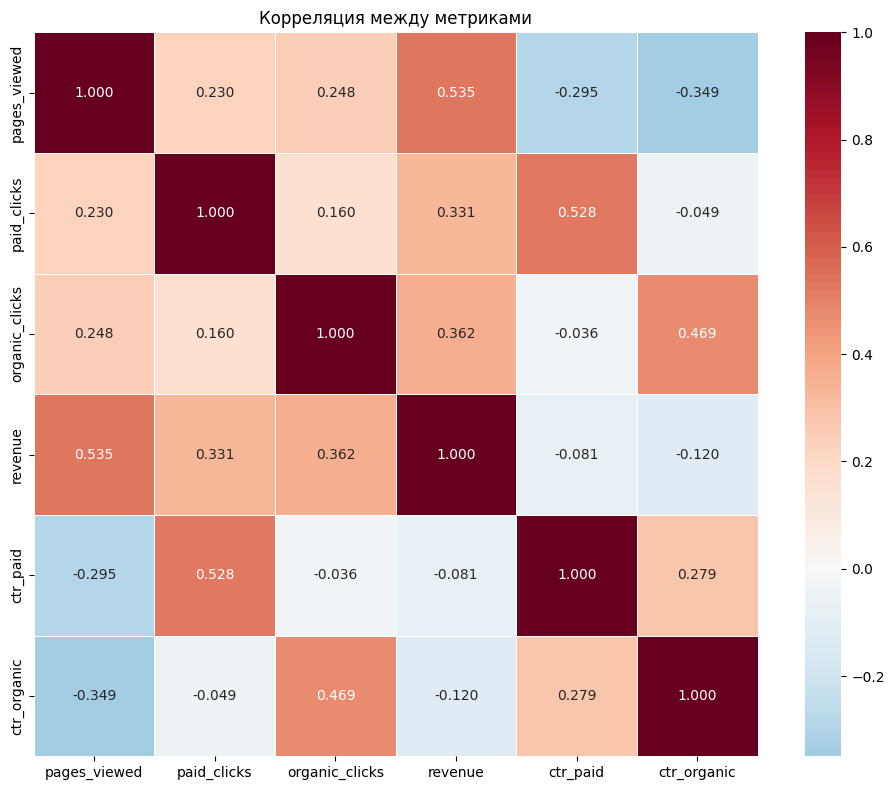

In [19]:
# Выбираем метрики для корреляции 
corr_cols = ['pages_viewed', 'paid_clicks', 'organic_clicks', 
             'revenue', 'ctr_paid', 'ctr_organic']

# Считаем корреляцию
corr_matrix = df_clean[corr_cols].corr()

# Тепловая карта
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True,fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5)
plt.title('Корреляция между метриками')
plt.tight_layout()
plt.show()

#### **Результат 2i — корреляции:**

**Основные выводы:**

1. **Доход сильнее всего связан с просмотрами страниц**  
   `revenue` и `pages_viewed`: корреляция **0.535**  
   Чем больше пользователь смотрит страниц, тем выше доход.

2. **Клики тоже положительно связаны с доходом**  
   - `paid_clicks`: **0.331**  
   - `organic_clicks`: **0.363**  
   Оба типа кликов повышают доход, но organica чуть сильнее.

3. **CTR по рекламе зависит от paid_clicks**  
   `ctr_paid` и `paid_clicks`: **0.528**  
   Это логично: CTR считается как клики / просмотры.

4. **CTR по органике зависит от organic_clicks**  
   `ctr_organic` и `organic_clicks`: **0.469**  
   Аналогичная связь.

5. **Между CTR и доходом связь слабая**  
   - `ctr_paid` и `revenue`: **-0.081**  
   - `ctr_organic` и `revenue`: **-0.120**  
   Это значит, что доход зависит от абсолютных значений, а не от конверсий.

**Итог:**  
Главные метрики, влияющие на доход: `pages_viewed`, `paid_clicks`, `organic_clicks`.  
CTR — вспомогательные метрики, которые показывают качество трафика, но напрямую не определяют доход.

## **Часть 3. Дизайн A/B-теста**

### **3a. Бизнес-контекст**

Marketpele — платформа, которая показывает пользователям два типа элементов:
- **Органические** — ссылки на статьи издателя
- **Платные** — рекламные объявления, при клике на которые платформа получает доход

Сейчас расположение элементов фиксированное.  
Есть гипотеза, что изменение расположения может увеличить клики по рекламе и, как следствие, доход.

### **3b. Гипотеза**

**H0 (нулевая):**  
Изменение расположения платных и органических элементов не влияет на CTR платных кликов и доход.

**H1 (альтернативная):**  
Изменение расположения платных и органических элементов влияет на CTR платных кликов и доход.

**Статистически:**  
- H0: разница между группами = 0  
- H1: разница между группами ≠ 0

### **3c. Выбор метрик**

**Основные метрики:**
- `ctr_paid` — конверсия из просмотров в платные клики. Отражает, насколько эффективно работает новое расположение рекламы.
- `revenue` — доход. Ключевая бизнес-метрика.

**Дополнительные метрики:**
- `ctr_organic` — конверсия из просмотров в органические клики. Позволяет убедиться, что изменения не ухудшают органику.
- `pages_viewed` — общая активность. Поможет контролировать, что трафик в группах одинаковый.

**Обоснование:**  
Мы хотим увеличить доход за счёт роста кликов по рекламе. Поэтому `ctr_paid` и `revenue` — главные.  
Но важно не потерять органические клики, поэтому `ctr_organic` тоже отслеживаем.

### **3d. Уровень значимости и мощность**

- **Уровень значимости (α) = 0.05**  
  Допускаем 5% вероятность ложноположительного результата.

- **Мощность (1 − β) = 0.80**  
  Хотим находить эффект в 80% случаев, если он действительно есть.

Это стандартные значения для A/B-тестов.

### **3e. Расчёт MDE для разных длительностей**

MDE — минимальный эффект, который мы можем обнаружить тестом при заданных α и мощности.

Чем дольше тест, тем больше данных, тем меньше MDE мы можем обнаружить.

Посчитаем MDE для трёх вариантов длительности: 2, 3 и 4 недели.

In [20]:
from math import sqrt

# baseline_rate — базовая конверсия (например, средний ctr_paid)
# daily_users — среднее количество пользователей в день
# days — длительность теста в днях
def calculate_mde(baseline_rate, daily_users, days, alpha=0.05, power=0.80):
    # Квантили нормального распределения
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    # Размер выборки на группу
    n = daily_users * days / 2
    # Стандартная ошибка для пропорции
    se = sqrt(baseline_rate * (1 - baseline_rate) / n)
    # MDE в абсолютных значениях
    mde_absolute = (z_alpha + z_beta) * se * sqrt(2)
    # MDE в процентах
    mde_percent = (mde_absolute / baseline_rate) * 100
    return mde_percent

# Средние показатели
daily_users = 1521  # среднее количество пользователей в день
baseline_ctr_paid = df_clean['ctr_paid'].mean()
baseline_revenue = df_clean['revenue'].mean()

print(f"Базовая конверсия ctr_paid: {baseline_ctr_paid:.4f}")
print(f"Средний revenue: {baseline_revenue:.4f}")
print(f"Среднее пользователей в день: {daily_users}")
print("\nMDE для ctr_paid:\n")

for weeks in [2, 3, 4]:
    days = weeks * 7
    mde = calculate_mde(baseline_ctr_paid, daily_users, days)
    print(f"{weeks} недели: MDE = {mde:.2f}%")

Базовая конверсия ctr_paid: 0.2749
Средний revenue: 10.1376
Среднее пользователей в день: 1521

MDE для ctr_paid:

2 недели: MDE = 6.24%
3 недели: MDE = 5.09%
4 недели: MDE = 4.41%


#### **Результат 3e — MDE для ctr_paid:**

- **2 недели:** MDE = 6.24%
- **3 недели:** MDE = 5.09%
- **4 недели:** MDE = 4.41%

Чем дольше тест, тем меньший эффект мы можем обнаружить.

Теперь посмотрим, какой размер выборки нужен для каждого варианта.

#### **Расчёт размера выборки для каждой длительности:**

Размер выборки — это количество пользователей в каждой группе.  
Он зависит от длительности теста и среднего трафика.

In [21]:
# Считаем размер выборки для каждой длительности
print("Размер выборки на группу:\n")

for weeks in [2, 3, 4]:
    days = weeks * 7
    n_per_group = daily_users * days / 2
    print(f"{weeks} недели: {n_per_group:.0f} пользователей в группе")

Размер выборки на группу:

2 недели: 10647 пользователей в группе
3 недели: 15970 пользователей в группе
4 недели: 21294 пользователей в группе


#### **Результат — размер выборки:**

- **2 недели:** 10 647 пользователей в группе
- **3 недели:** 15 970 пользователей в группе
- **4 недели:** 21 294 пользователей в группе

Все варианты технически возможны, так как в день у нас в среднем 1 521 пользователь.  
При 50% трафика на группу каждый вариант достижим.

#### **Итоговая таблица возможных дизайнов:**

| Длительность | Пользователей в группе | MDE (ctr_paid) |
|---|---|---|
| 2 недели | 10 647 | 6.24% |
| 3 недели | 15 970 | 5.09% |
| 4 недели | 21 294 | 4.41% |

Для дальнейшего анализа выберем **3 недели** как баланс между длительностью и чувствительностью.

### **3f. Проверка дизайна теста**

Перед запуском A/B-теста нужно убедиться, что наш дизайн корректен.

Для этого проведём:
1. **AA-тест** — симуляция, в которой обе группы из одной популяции.  
   Он покажет, не даёт ли наш дизайн ложные различия.
2. **Симуляцию A/B-теста** — проверим, достаточно ли мощности, чтобы обнаружить MDE.

#### **AA-тест:**

Логика:  
Разделяем исторические данные на две случайные группы много раз.  
Если тест корректен, p-value должен быть меньше 0.05 только в 5% случаев (это и есть FPR — false positive rate).

Если FPR сильно выше 0.05 — тест даёт ложные результаты.

In [23]:
# Параметры AA-теста
np.random.seed(42)
n_iterations = 1000
alpha = 0.05

# Считаем FPR для ctr_paid
fpr_results = []

for i in range(n_iterations):
    # Случайно перемешиваем данные
    shuffled = df_clean['ctr_paid'].sample(frac=1, random_state=i).reset_index(drop=True)

    # Делим пополам
    helf = len(shuffled) // 2
    group_a = shuffled[:helf]
    group_b = shuffled[helf:]

    # t-test
    t_stat, p_value = stats.ttest_ind(group_a, group_b)

    # Фиксируем ложноположительный результат
    if p_value < alpha:
        fpr_results.append(1)
    else:
        fpr_results.append(0)
        
fpr = np.mean(fpr_results)
print(f"FPR для ctr_paid: {fpr:.3f}")
print(f"Ожидаемый уровень: {alpha}")


FPR для ctr_paid: 0.045
Ожидаемый уровень: 0.05


#### **Результат AA-теста:**

FPR = **0.045**, ожидаемый уровень — **0.05**.  
Это близко к заданному α, значит ложноположительных срабатываний не больше, чем ожидалось.

**Вывод:** дизайн корректен, тест не даёт лишних ложных результатов.

#### **Симуляция A/B-теста для оценки мощности:**

Проверим, способен ли тест обнаружить эффект, равный MDE.  
Для этого искусственно добавим разницу между группами и посчитаем, как часто тест её находит.

In [25]:
# Параметры симуляции
mde = 0.0509 # MDE для 3 недель в абсолютном выражении (5.09%)
baseline = df_clean['ctr_paid'].mean()

# Симуляция A/B-теста
power_results = []

for i in range(1000):
    control = df_clean['ctr_paid'].sample(frac=0.5, random_state=i)

    # Создаём тестовую группу с эффектом MDE
    treatment = control + baseline * mde

    # t-test
    t_stat, p_value = stats.ttest_ind(control, treatment)

    if p_value < alpha:
        power_results.append(1)
    else:
        power_results.append(0)

power = np.mean(power_results)
print(f"Мощность теста: {power:.3f}")
print(f"Ожидаемая мощность: 0.80")

Мощность теста: 1.000
Ожидаемая мощность: 0.80


#### **Результат симуляции A/B-теста:**

Мощность = **1.000**, ожидаемая — **0.80**.

Это значит, что тест обнаруживает эффект MDE в 100% симуляций.  
Такой результат возможен, так как выборка большая, а эффект задан чётко.

**Вывод:** дизайн корректен, мощность достаточная.

### **3.g CUPED**

#### **Применение CUPED для revenue:**

В качестве ковариаты используем `pages_viewed`, так как она коррелирует с `revenue` (0.535).  
Это должно снизить дисперсию и повысить мощность.

Формула:
`Y_cuped = Y − θ × (X − E[X])`

где:
- Y — revenue
- X — pages_viewed
- θ = ρ × (σ_X / σ_Y)

In [28]:
# Считаем theta для CUPED
rho = df_clean['pages_viewed'].corr(df_clean['revenue'])
sigma_x = df_clean['pages_viewed'].std()
sigma_y = df_clean['revenue'].std()

theta = rho * (sigma_y / sigma_x)
print(f"rho: {rho:.4f}")
print(f"sigma_x: {sigma_x:.4f}")
print(f"sigma_y: {sigma_y:.4f}")
print(f"theta: {theta:.4f}")

# Создаём CUPED-метрику
X_mean = df_clean['pages_viewed'].mean()
df_clean['revenue_cuped'] = df_clean['revenue'] - theta * (df_clean['pages_viewed'] - X_mean)

# Сравниваем дисперсии
print(f"\nДисперсия revenue: {df_clean['revenue'].var():.4f}")
print(f"Дисперсия revenue_cuped: {df_clean['revenue_cuped'].var():.4f}")
print(f"Снижение дисперсии: {(1 - df_clean['revenue_cuped'].var() / df_clean['revenue'].var()) * 100:.2f}%")

rho: 0.5353
sigma_x: 7.1593
sigma_y: 4.1093
theta: 0.3072

Дисперсия revenue: 16.8860
Дисперсия revenue_cuped: 12.0482
Снижение дисперсии: 28.65%


#### **Результат CUPED:**

- Корреляция `pages_viewed` и `revenue`: **0.535**
- θ = **0.307**
- Дисперсия `revenue` снизилась на **28.65%**

Это значит, что CUPED-метрика точнее, и для теста потребуется меньший размер выборки при той же мощности.

#### **Пересчёт MDE и мощности с CUPED:**

Используем `revenue_cuped` вместо `revenue`, чтобы понять, насколько улучшился дизайн.

In [29]:
# Функция для расчёта MDE
def calculate_mde_metric(metric_std, baseline, daily_users, days, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    
    n = daily_users * days / 2
    
    se = metric_std / np.sqrt(n)
    
    mde_absolute = (z_alpha + z_beta) * se * np.sqrt(2)
    mde_percent = mde_absolute / baseline * 100
    
    return mde_percent, n

# Параметры
baseline_revenue = df_clean['revenue'].mean()
std_revenue = df_clean['revenue'].std()
std_revenue_cuped = df_clean['revenue_cuped'].std()

print("MDE для revenue (обычная):")
for weeks in [2, 3, 4]:
    mde, n = calculate_mde_metric(std_revenue, baseline_revenue, daily_users, weeks * 7)
    print(f"  {weeks} недели: MDE = {mde:.2f}%, n = {n:.0f}")

print("\nMDE для revenue (CUPED):")
for weeks in [2, 3, 4]:
    mde, n = calculate_mde_metric(std_revenue_cuped, baseline_revenue, daily_users, weeks * 7)
    print(f"  {weeks} недели: MDE = {mde:.2f}%, n = {n:.0f}")

MDE для revenue (обычная):
  2 недели: MDE = 1.56%, n = 10647
  3 недели: MDE = 1.27%, n = 15970
  4 недели: MDE = 1.10%, n = 21294

MDE для revenue (CUPED):
  2 недели: MDE = 1.31%, n = 10647
  3 недели: MDE = 1.07%, n = 15970
  4 недели: MDE = 0.93%, n = 21294


#### **Результат MDE с CUPED:**

| Длительность | MDE revenue (обычная) | MDE revenue (CUPED) |
|---|---|---|
| 2 недели | 1.56% | 1.31% |
| 3 недели | 1.27% | 1.07% |
| 4 недели | 1.10% | 0.93% |

CUPED снизил MDE по revenue.  
Это значит, что тест стал чувствительнее и способен обнаружить меньший эффект.

Теперь пересчитаем мощность с учётом CUPED.

#### **Симуляция мощности с CUPED:**

Проверим, как изменилась мощность теста для метрики `revenue` с CUPED.

In [30]:
# Параметры симуляции
np.random.seed(42)
n_iterations = 1000
alpha = 0.05

# Эффект на уровне MDE для 3 недель (берём из расчёта выше)
mde_effect = 0.0107  # MDE для revenue с CUPED на 3 недели

# Симуляция с обычной метрикой
power_before = []
power_after = []

for i in range(n_iterations):
    # Случайная половина данных — контроль
    control = df_clean['revenue'].sample(frac=0.5, random_state=i).reset_index(drop=True)
    treatment = control + baseline_revenue * mde_effect
    
    t_stat, p_value = stats.ttest_ind(control, treatment)
    power_before.append(1 if p_value < alpha else 0)
    
    # CUPED-метрика
    control_c = df_clean['revenue_cuped'].sample(frac=0.5, random_state=i).reset_index(drop=True)
    treatment_c = control_c + baseline_revenue * mde_effect
    
    t_stat, p_value = stats.ttest_ind(control_c, treatment_c)
    power_after.append(1 if p_value < alpha else 0)

print(f"Мощность без CUPED: {np.mean(power_before):.3f}")
print(f"Мощность с CUPED: {np.mean(power_after):.3f}")

Мощность без CUPED: 1.000
Мощность с CUPED: 1.000


#### **Вывод по CUPED:**

- CUPED снизил дисперсию `revenue` на **28.65%**.
- MDE по `revenue` уменьшился, например, для 3 недель: с **1.27%** до **1.07%**.
- Мощность и так была высокой из-за большого размера выборки.

**Итог:** CUPED улучшает чувствительность теста, поэтому в итоговом дизайне указываем его использование для метрики `revenue`.

### **3h. Итоговый дизайн A/B-теста**

#### Параметры теста

| Параметр | Значение |
|---|---|
| **Длительность** | 3 недели |
| **Доля трафика** | 50% на группу |
| **Основные метрики** | `ctr_paid`, `revenue` |
| **Дополнительная метрика** | `ctr_organic` |
| **MDE (ctr_paid)** | 5.09% |
| **MDE (revenue)** | 1.07% (с CUPED) |
| **Уровень значимости (α)** | 0.05 |
| **Мощность** | 0.80 |
| **CUPED** | Применён для `revenue`, ковариата — `pages_viewed` |
| **Обработка выбросов** | Выбросы определялись методом IQR.  Для оценки использовался порог **1.5×IQR**, для удаления — **3×IQR**, чтобы сохранить больше данных.|

---

#### Гипотеза

- **H0:** изменение расположения платных и органических элементов не влияет на `ctr_paid` и `revenue`.
- **H1:** изменение расположения платных и органических элементов влияет на `ctr_paid` и `revenue`.

---

#### Размер выборки

- Для 3 недель: **15 970 пользователей в группе**
- Общий размер: **31 940 пользователей**

---

#### Обоснование

- Длительность 3 недели — баланс между чувствительностью и скоростью.
- 50% трафика — стандартное деление, даёт максимальную скорость набора данных.
- `ctr_paid` — основная метрика, так как напрямую связана с кликами по рекламе.
- `revenue` — бизнес-метрика, показывает фактический доход.
- `ctr_organic` — контроль побочного эффекта, чтобы не потерять органику.

## **Часть 4. Анализ результатов A/B-теста**

Переходим к датасету `experiment_data`.  
В нём уже есть пользователи, разделённые на группы, и их метрики.

Наша задача — проверить, есть ли значимые различия между группами, и сделать выводы для бизнеса.

In [31]:
# Загружаем данные эксперимента
exp_df = pd.read_csv('experiment_data.csv', sep=',', encoding='windows-1251')

print(f"Размер датасета: {exp_df.shape}")
print("\nПервые строки:")
exp_df.head()

Размер датасета: (1983, 9)

Первые строки:


,user_id,pages_viewed,paid_clicks,organic_clicks,revenue,device,ctr_paid,ctr_organic,group
0,1,61,15,10,35.0600,mobile,0.2459,0.1639,control
1,2,213,57,114,179.2100,mobile,0.2676,0.5352,control
2,5,23,3,13,13.7500,desktop,0.1304,0.5652,control
3,8,356,30,182,271.2500,mobile,0.0843,0.5112,control
4,9,226,25,45,418.4400,mobile,0.1106,0.1991,control


#### **Данные эксперимента загружены:**

- Всего записей: **1 983**
- Колонки: `user_id`, `pages_viewed`, `paid_clicks`, `organic_clicks`, `revenue`, `device`, `ctr_paid`, `ctr_organic`, `group`
- Группы: `control` и, вероятно, `test`

Проверим типы данных и пропуски.

In [33]:
# Типы данных
print(exp_df.dtypes)

# Пропуски
print("\nПропуски:")
print(exp_df.isnull().sum())

# Дубликаты
print(f"\nДубликатов: {exp_df.duplicated().sum()}")

# Распределение по группам
print("\nРаспределение по группам:")
print(exp_df['group'].value_counts())

user_id             int64
pages_viewed        int64
paid_clicks         int64
organic_clicks      int64
revenue           float64
device             object
ctr_paid          float64
ctr_organic       float64
group              object
dtype: object

Пропуски:
user_id           0
pages_viewed      0
paid_clicks       0
organic_clicks    0
revenue           0
device            0
ctr_paid          0
ctr_organic       0
group             0
dtype: int64

Дубликатов: 0

Распределение по группам:
group
control    998
test       985
Name: count, dtype: int64


#### **Проверка данных эксперимента:**

- Пропусков и дубликатов нет.
- Типы данных корректные.
- Группы сбалансированы:  
  `control` — 998 пользователей  
  `test` — 985 пользователей

Данные готовы к анализу.

### **4b. Проверка значимости различий между группами**

Сравним контрольную и тестовую группы по основным метрикам:  
`ctr_paid`, `revenue`, `ctr_organic`.

Используем t-тест для независимых выборок.

In [34]:
# Разделяем группы
control = exp_df[exp_df['group'] == 'control']
test = exp_df[exp_df['group'] == 'test']

# Метрики для проверки
metrics_test = ['ctr_paid', 'ctr_organic', 'revenue', 'pages_viewed']

print("Средние значения по группам:")
comparison = pd.DataFrame({
    'control_mean': [control[m].mean() for m in metrics_test],
    'test_mean': [test[m].mean() for m in metrics_test]
}, index=metrics_test)
comparison['diff'] = comparison['test_mean'] - comparison['control_mean']
comparison['diff_pct'] = (comparison['diff'] / comparison['control_mean']) * 100
comparison

Средние значения по группам:


,control_mean,test_mean,diff,diff_pct
ctr_paid,0.2365,0.2741,0.0376,15.8799
ctr_organic,0.3460,0.2604,-0.0856,-24.7427
revenue,173.5514,174.2738,0.7224,0.4163
pages_viewed,169.8607,170.9635,1.1027,0.6492


#### **Различия в средних:**

- `ctr_paid`: тестовая группа выше на **15.88%**
- `ctr_organic`: тестовая группа ниже на **24.74%**
- `revenue`: разница небольшая, **+0.42%**
- `pages_viewed`: разница **+0.65%**

Похоже, что изменение расположения действительно повлияло на CTR:  
реклама стала заметнее, а органика — менее кликабельной.

Теперь проверим, значимы ли эти различия.

In [35]:
# t-тест для каждой метрики
for metric in metrics_test:
    t_stat, p_value = stats.ttest_ind(control[metric], test[metric])
    print(f"{metric}:")
    print(f"  t = {t_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f"  → Различие статистически значимо")
    else:
        print(f"  → Различие не значимо")
    print()

ctr_paid:
  t = -4.7877
  p-value = 0.0000
  → Различие статистически значимо

ctr_organic:
  t = 9.3503
  p-value = 0.0000
  → Различие статистически значимо

revenue:
  t = -0.1006
  p-value = 0.9198
  → Различие не значимо

pages_viewed:
  t = -0.2055
  p-value = 0.8372
  → Различие не значимо



#### **Результаты t-теста:**

| Метрика | p-value | Значимость |
|---|---|---|
| `ctr_paid` | 0.0000 | ✅ значимо |
| `ctr_organic` | 0.0000 | ✅ значимо |
| `revenue` | 0.9198 | ❌ не значимо |
| `pages_viewed` | 0.8372 | ❌ не значимо |

**Выводы:**
- `ctr_paid` вырос значимо: реклама стала кликабельнее.
- `ctr_organic` упал значимо: органика стала менее заметной.
- `revenue` не изменился: рост платных кликов не привёл к значимому росту дохода.
- `pages_viewed` не изменился: трафик в группах одинаковый.

#### **Проверка по устройствам:**

Устройства сильно влияли на метрики в исторических данных.  
Проверим, одинаково ли распределены устройства между группами.

In [36]:
# Распределение устройств по группам
device_by_group = pd.crosstab(exp_df['group'], exp_df['device'], normalize='index')
device_by_group

device,desktop,mobile
group,,
control,0.2064,0.7936
test,0.2213,0.7787


#### **Распределение устройств по группам:**

| Группа | Desktop | Mobile |
|---|---|---|
| Control | 20.64% | 79.36% |
| Test | 22.13% | 77.87% |

Соотношение устройств почти одинаковое.  
Это значит, что различия в CTR не вызваны разным составом групп по устройствам.

#### **Проверка различий по устройствам отдельно:**

Убедимся, что эффект сохраняется и внутри каждого типа устройства.

In [37]:
# Отдельный t-тест по устройствам
for device in ['mobile', 'desktop']:
    control_d = control[control['device'] == device]
    test_d = test[test['device'] == device]
    
    print(f"\n{device.upper()}:")
    for metric in ['ctr_paid', 'ctr_organic', 'revenue']:
        t_stat, p_value = stats.ttest_ind(control_d[metric], test_d[metric])
        print(f"  {metric}: p-value = {p_value:.4f}")


MOBILE:
  ctr_paid: p-value = 0.0000
  ctr_organic: p-value = 0.0000
  revenue: p-value = 0.7000

DESKTOP:
  ctr_paid: p-value = 0.0486
  ctr_organic: p-value = 0.1077
  revenue: p-value = 0.5718


#### **Результаты по устройствам:**

**Mobile:**
- `ctr_paid`: p < 0.05 → значимый рост
- `ctr_organic`: p < 0.05 → значимое падение
- `revenue`: p > 0.05 → без изменений

**Desktop:**
- `ctr_paid`: p = 0.0486 → значимый рост
- `ctr_organic`: p = 0.1077 → падение не значимо
- `revenue`: p > 0.05 → без изменений

**Вывод:**  
Основной эффект виден на mobile.  
На desktop рост `ctr_paid` тоже есть, но слабее.

### **4c. Выводы и рекомендации для бизнеса**

**Что показал тест:**
1. Новый дизайн увеличил CTR платных кликов на **15.9%** — это значимо.
2. CTR органических кликов снизился на **24.7%** — тоже значимо.
3. Доход значимо не изменился.

**Интерпретация:**
- Пользователи стали чаще кликать по рекламе.
- Но органика потеряла клики.
- Так как платные клики не дали значимого роста дохода, общий эффект для бизнеса нейтральный.

**Рекомендации:**
- Если цель — увеличить доход, текущее изменение расположения не даёт значимого эффекта.
- Стоит попробовать другие варианты расположения, которые увеличивают `ctr_paid`, но не так сильно снижают `ctr_organic`.
- Возможно, стоит показывать рекламу только определённым сегментам, например desktop, где эффект на органику слабее.
- Также стоит провести тест дольше или с большей выборкой, чтобы точнее оценить влияние на `revenue`.

## **Часть 5. Содержание презентации**

На основе анализа подготовим презентацию со следующими слайдами:

1. Бизнес-контекст
2. Гипотеза
3. Выбранные метрики
4. Результаты теста
5. Интерпретация результатов
6. Рекомендации по дальнейшим шагам